# Importar Librerias

In [43]:
import pandas as pd
import numpy as np
import re
import string
import json
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report, confusion_matrix)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de cómputo: {DEVICE}")

Dispositivo de cómputo: cuda


## Lectura de datos

In [2]:
file_path = 'movie.csv'
df = pd.read_csv(file_path)

## Exploración de datos

En esta sección se carga el df (`Train_textosODS.xlsx`), se revisan dimensiones, nombres de columnas (`shape`, `columns`) y la estructura de los datos con `info()` (tipos, nulos). Con `head()` se inspeccionan las primeras filas para comprobar el formato de los textos y la variable objetivo ODS.

### Hallazgos del analisis exploratorio
El conjunto de datos está compuesto por textos asociados a 16 Objetivos de Desarrollo Sostenible (ODS), al analizar la distribución de los textos por clase se observa que los ODS 16, 5 y 4 concentran la mayor cantidad de textos, mientras que los ODS 12, 15 y 9 presentan la menor cantidad de textos, No obstante, el desbalance entre clases es moderado y no representa una diferencia extrema entre el ODS con mayor y menor número de textos, adicional el df no contiene textos vacíos ni registros duplicados.

Se observaron las siguientes características:

- Promedio de palabras en el texto son 111 palabras
- El minimo de palabras en un texto fue de 24 palabras
- El maximo de palabras en un texto fue de 268 palabras

Finalmente al analizar el corpus se identificó un vocabulario aproximado de 35000 términos únicos, lo que refleja la alta dimensionalidad de característica de los problemas de procesamiento de lenguaje natural.

In [4]:
# Primeras 5 filas
df.head()

,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


In [5]:
print("Exploración Inicial")
print(f"Shape             : {df.shape}")
print(f"Columnas          : {df.columns.tolist()}")
print(f"Valores nulos     :\n{df.isnull().sum()}")

Exploración Inicial
Shape             : (40000, 2)
Columnas          : ['text', 'label']
Valores nulos     :
text     0
label    0
dtype: int64


In [6]:
print(f"\nDistribución de clases:\n{df['label'].value_counts()}")


Distribución de clases:
label
0    20019
1    19981
Name: count, dtype: int64


In [7]:
print(f"\nEjemplo positivo:\n{df[df['label']==1]['text'].iloc[0][:200]}")
print(f"\nEjemplo negativo:\n{df[df['label']==0]['text'].iloc[0][:200]}")


Ejemplo positivo:
Im a die hard Dads Army fan and nothing will ever change that. I got all the tapes, DVD's and audiobooks and every time i watch/listen to them its brand new. <br /><br />The film. The film is a re run

Ejemplo negativo:
I grew up (b. 1965) watching and loving the Thunderbirds. All my mates at school watched. We played "Thunderbirds" before school, during lunch and after school. We all wanted to be Virgil or Scott. No


In [8]:
# Longitud en caracteres de cada texto (número de caracteres por fila)
df["char_count"]   = df["text"].apply(len)
# Longitud en palabras: split por espacios y cuenta de tokens por texto
df["word_count"]   = df["text"].apply(lambda x: len(x.split()))
# COMENTARIO
df["unique_words"] = df["text"].apply(lambda x: len(set(x.lower().split())))
# COMENTARIO
df["avg_word_len"] = df["text"].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
)
# COMENTARIO
df["sent_label"] = df["label"].map({1: "Positiva", 0: "Negativa"})

In [ ]:
print("\n--- Estadísticas descriptivas por clase ---")
print(
    df.groupby("sent_label")[["char_count", "word_count", "unique_words", "avg_word_len"]]
    .describe()
    .T
)


--- Estadísticas descriptivas por clase ---
sent_label              Negativa      Positiva
char_count   count  20019.000000  19981.000000
             mean    1292.536990   1328.083279
             std      942.220087   1032.236721
             min       32.000000     65.000000
             25%      705.000000    690.000000
             50%      973.000000    972.000000
             75%     1571.000000   1621.000000
             max     8969.000000  13704.000000
word_count   count  20019.000000  19981.000000
             mean     229.204606    233.477954
             std      164.326729    177.787207
             min        4.000000     12.000000
             25%      128.000000    125.000000
             50%      174.000000    173.000000
             75%      279.000000    285.000000
             max     1522.000000   2470.000000
unique_words count  20019.000000  19981.000000
             mean     147.970128    148.287873
             std       85.685150     91.743160
             mi

: 

: 

In [19]:
PAL = {"Positiva": "#388697", "Negativa": "#DB162F"}
BG  = "#f8f9fa"

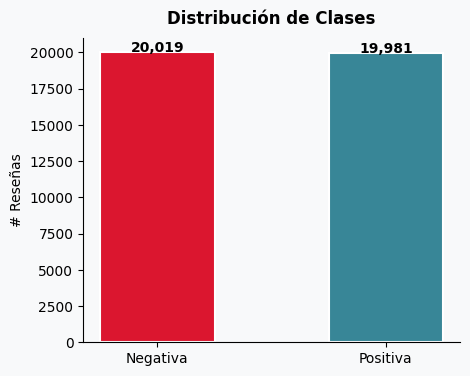

: 

: 

In [ ]:
fig = plt.figure(figsize=(18, 22), facecolor=BG)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0]) # Create an Axes object using the first grid position from gs
vc = df["sent_label"].value_counts()
bars = ax1.bar(
    vc.index, vc.values,
    color=[PAL[k] for k in vc.index],
    width=0.5, edgecolor="white", linewidth=1.5,
)
for b in bars:
    ax1.text(
        b.get_x() + b.get_width() / 2, b.get_height() + 30,
        f"{int(b.get_height()):,}", ha="center", fontweight="bold",
    )
pct = vc / vc.sum() * 100
ax1.set_title("Distribución de Clases", fontweight="bold", pad=10)
ax1.set_ylabel("# Reseñas"); ax1.set_facecolor(BG)
ax1.spines[["top", "right"]].set_visible(False)
plt.show()

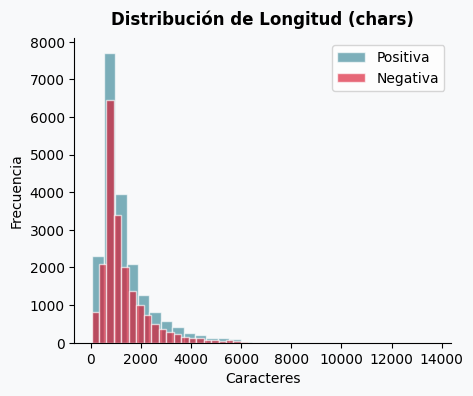

: 

: 

In [ ]:
fig = plt.figure(figsize=(18, 22), facecolor=BG)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.35)
ax2 = fig.add_subplot(gs[0, 1])
for label, color in PAL.items():
    ax2.hist(
        df[df["sent_label"] == label]["char_count"],
        bins=30, alpha=0.65, color=color, label=label, edgecolor="white",
    )
ax2.set_title("Distribución de Longitud (chars)", fontweight="bold", pad=10)
ax2.set_xlabel("Caracteres"); ax2.set_ylabel("Frecuencia")
ax2.legend(); ax2.set_facecolor(BG)
ax2.spines[["top", "right"]].set_visible(False)
plt.show()

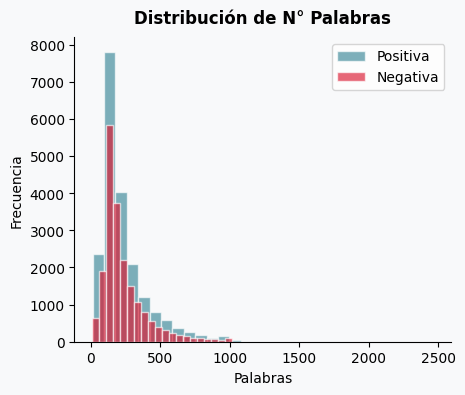

: 

: 

In [ ]:
fig = plt.figure(figsize=(18, 22), facecolor=BG)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.35)
ax3 = fig.add_subplot(gs[0, 2])
for label, color in PAL.items():
    ax3.hist(
        df[df["sent_label"] == label]["word_count"],
        bins=30, alpha=0.65, color=color, label=label, edgecolor="white",
    )
ax3.set_title("Distribución de N° Palabras", fontweight="bold", pad=10)
ax3.set_xlabel("Palabras"); ax3.set_ylabel("Frecuencia")
ax3.legend(); ax3.set_facecolor(BG)
ax3.spines[["top", "right"]].set_visible(False)
plt.show()

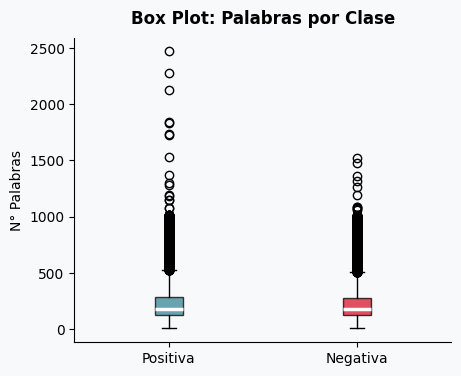

: 

: 

In [ ]:
fig = plt.figure(figsize=(18, 22), facecolor=BG)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.35)
ax4 = fig.add_subplot(gs[1, 0])
data_box = [df[df["sent_label"] == l]["word_count"].values for l in ["Positiva", "Negativa"]]
bp = ax4.boxplot(
    data_box, labels=["Positiva", "Negativa"], patch_artist=True,
    medianprops=dict(color="white", linewidth=2.5),
)
for patch, color in zip(bp["boxes"], PAL.values()):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax4.set_title("Box Plot: Palabras por Clase", fontweight="bold", pad=10)
ax4.set_ylabel("N° Palabras"); ax4.set_facecolor(BG)
ax4.spines[["top", "right"]].set_visible(False)
plt.show()

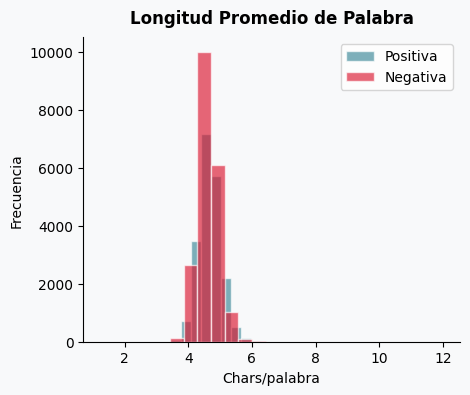

: 

: 

In [ ]:
fig = plt.figure(figsize=(18, 22), facecolor=BG)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.35)
ax5 = fig.add_subplot(gs[1, 1])
for label, color in PAL.items():
    ax5.hist(
        df[df["sent_label"] == label]["avg_word_len"],
        bins=20, alpha=0.65, color=color, label=label, edgecolor="white",
    )
ax5.set_title("Longitud Promedio de Palabra", fontweight="bold", pad=10)
ax5.set_xlabel("Chars/palabra"); ax5.set_ylabel("Frecuencia")
ax5.legend(); ax5.set_facecolor(BG)
ax5.spines[["top", "right"]].set_visible(False)
plt.show()

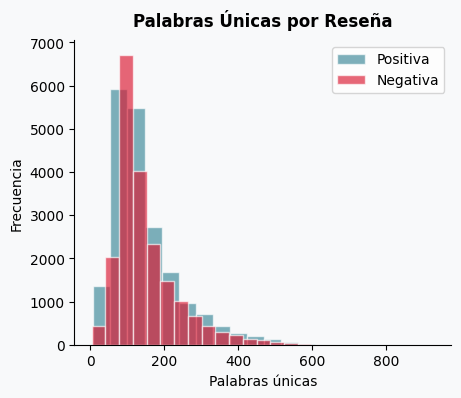

: 

: 

In [ ]:
fig = plt.figure(figsize=(18, 22), facecolor=BG)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.35)
ax6 = fig.add_subplot(gs[1, 2])
for label, color in PAL.items():
    ax6.hist(
        df[df["sent_label"] == label]["unique_words"],
        bins=20, alpha=0.65, color=color, label=label, edgecolor="white",
    )
ax6.set_title("Palabras Únicas por Reseña", fontweight="bold", pad=10)
ax6.set_xlabel("Palabras únicas"); ax6.set_ylabel("Frecuencia")
ax6.legend(); ax6.set_facecolor(BG)
ax6.spines[["top", "right"]].set_visible(False)

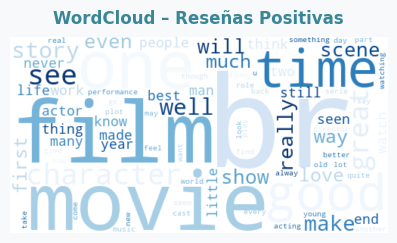

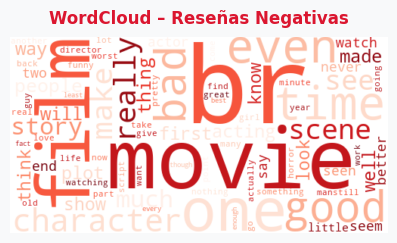

: 

: 

In [ ]:
for label, colormap, col in [("Positiva", "Blues", 0), ("Negativa", "Reds", 2)]:
    fig = plt.figure(figsize=(18, 22), facecolor=BG)
    gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.35)
    ax = fig.add_subplot(gs[2, col])
    text = " ".join(df[df["sent_label"] == label]["text"])
    wc = WordCloud(
        width=500, height=260, background_color="white",
        colormap=colormap, max_words=80, collocations=False,
    ).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"WordCloud – Reseñas {label}s", fontweight="bold",
                 pad=10, color=PAL[label])
    plt.show()

## Preparación de los datos

DESCRIPCION DE LO QUE SE HIZO

In [9]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,       # 80 % entrenamiento, 20 % prueba
    random_state=SEED,
    stratify=df['label'] # garantiza balance de clases en cada split
)

train_texts = train_df['text'].tolist()
train_labels = train_df['label'].tolist()

test_texts = test_df['text'].tolist()
test_labels = test_df['label'].tolist()

print(f"Train: {len(train_texts)} muestras | Test: {len(test_texts)} muestras")

Train: 32000 muestras | Test: 8000 muestras


In [22]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)        # elimina tags HTML (comunes en IMDb)
    text = re.sub(r"[^a-z\s]", " ", text)     # elimina puntuación
    text = re.sub(r"\s+", " ", text).strip()  # normaliza espacios
    return text

In [25]:
def build_vocab(texts, max_size=20000):       # vocabulario más grande
    words = []
    for text in texts:
        words.extend(clean_text(text).split())
    freq = Counter(words)
    vocab = {word: i+1 for i, (word, _) in enumerate(freq.most_common(max_size))}
    return vocab
vocab = build_vocab(train_texts)

In [26]:
def encode(text, vocab, max_len=256):
    tokens = clean_text(text).split()
    idxs = [vocab.get(token, 0) for token in tokens]
    if len(idxs) < max_len:
        idxs += [0] * (max_len - len(idxs))
    else:
        idxs = idxs[:max_len]
    return idxs

In [27]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        x = torch.tensor(encode(self.texts[idx], self.vocab), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

train_dataset = TextDataset(train_texts, train_labels, vocab)
test_dataset = TextDataset(test_texts, test_labels, vocab)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [33]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=200, hidden_dim=254, output_dim=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])  # apply dropout on last hidden state
        out = self.fc(out)
        return out

model_rnn = RNNClassifier(vocab_size=len(vocab)).to(DEVICE)
print(model_rnn)

RNNClassifier(
  (embedding): Embedding(20001, 200, padding_idx=0)
  (rnn): RNN(200, 254, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=254, out_features=2, bias=True)
)


In [30]:
def plot_training_curves(history, PAL, BG):
    """
    Grafica las curvas de entrenamiento:
    - Loss (train vs val)
    - Accuracy, Precision, Recall y F1 (val)
    """
    epochs_range = range(1, len(history["train_loss"]) + 1)

    fig = plt.figure(figsize=(16, 10), facecolor=BG)
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    # ── 1. Loss ─────────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(epochs_range, history["train_loss"],
             color=PAL["Negativa"], linewidth=2, marker="o", markersize=4,
             label="Train Loss")
    ax1.plot(epochs_range, history["val_loss"],
             color=PAL["Positiva"], linewidth=2, marker="o", markersize=4,
             label="Val Loss")
    ax1.set_title("Curva de Loss", fontweight="bold", pad=10)
    ax1.set_xlabel("Época"); ax1.set_ylabel("Loss")
    ax1.legend(); ax1.set_facecolor(BG)
    ax1.spines[["top", "right"]].set_visible(False)

    # ── 2. Accuracy ──────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs_range, history["val_acc"],
             color=PAL["Positiva"], linewidth=2, marker="s", markersize=4,
             label="Val Accuracy")
    # Línea de referencia en el mejor accuracy
    best_acc = max(history["val_acc"])
    best_ep  = history["val_acc"].index(best_acc) + 1
    ax2.axvline(best_ep, color="gray", linestyle="--", linewidth=1, alpha=0.7)
    ax2.axhline(best_acc, color="gray", linestyle="--", linewidth=1, alpha=0.7)
    ax2.annotate(f"Best: {best_acc:.4f}",
                 xy=(best_ep, best_acc),
                 xytext=(best_ep + 0.3, best_acc - 0.02),
                 fontsize=9, color="gray")
    ax2.set_title("Accuracy (Validación)", fontweight="bold", pad=10)
    ax2.set_xlabel("Época"); ax2.set_ylabel("Accuracy")
    ax2.legend(); ax2.set_facecolor(BG)
    ax2.spines[["top", "right"]].set_visible(False)

    # ── 3. Precision y Recall ────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(epochs_range, history["val_precision"],
             color=PAL["Negativa"], linewidth=2, marker="^", markersize=4,
             label="Precision")
    ax3.plot(epochs_range, history["val_recall"],
             color=PAL["Positiva"], linewidth=2, marker="v", markersize=4,
             label="Recall")
    ax3.set_title("Precision y Recall (Validación)", fontweight="bold", pad=10)
    ax3.set_xlabel("Época"); ax3.set_ylabel("Score")
    ax3.legend(); ax3.set_facecolor(BG)
    ax3.spines[["top", "right"]].set_visible(False)

    # ── 4. F1-Score ──────────────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(epochs_range, history["val_f1"],
             color="#6A0572", linewidth=2, marker="D", markersize=4,
             label="F1-Score")
    best_f1 = max(history["val_f1"])
    best_f1_ep = history["val_f1"].index(best_f1) + 1
    ax4.axvline(best_f1_ep, color="gray", linestyle="--", linewidth=1, alpha=0.7)
    ax4.axhline(best_f1, color="gray", linestyle="--", linewidth=1, alpha=0.7)
    ax4.annotate(f"Best: {best_f1:.4f}",
                 xy=(best_f1_ep, best_f1),
                 xytext=(best_f1_ep + 0.3, best_f1 - 0.02),
                 fontsize=9, color="gray")
    ax4.set_title("F1-Score (Validación)", fontweight="bold", pad=10)
    ax4.set_xlabel("Época"); ax4.set_ylabel("F1")
    ax4.legend(); ax4.set_facecolor(BG)
    ax4.spines[["top", "right"]].set_visible(False)

    fig.suptitle("Curvas de Entrenamiento – LSTM Bidireccional",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.savefig("training_curves.png", dpi=150, bbox_inches="tight",
                facecolor=BG)
    plt.show()
    print("Figura guardada como training_curves.png")

Epoch 01 | Train Loss: 0.7012 | Val Loss: 0.6936 | Acc: 0.5050 | Prec: 0.5043 | Rec: 0.5235 | F1: 0.5138
           ✓ Mejor modelo guardado (val_loss=0.6936)
Epoch 02 | Train Loss: 0.7077 | Val Loss: 0.6942 | Acc: 0.5028 | Prec: 0.5017 | Rec: 0.6464 | F1: 0.5650
           Sin mejora 1/3
Epoch 03 | Train Loss: 0.7023 | Val Loss: 0.6985 | Acc: 0.4986 | Prec: 0.4974 | Rec: 0.3576 | F1: 0.4161
           Sin mejora 2/3
Epoch 04 | Train Loss: 0.7006 | Val Loss: 0.6981 | Acc: 0.5012 | Prec: 0.5006 | Rec: 0.6314 | F1: 0.5584
           Sin mejora 3/3

Early stopping activado en época 4.

Mejor modelo restaurado ✓


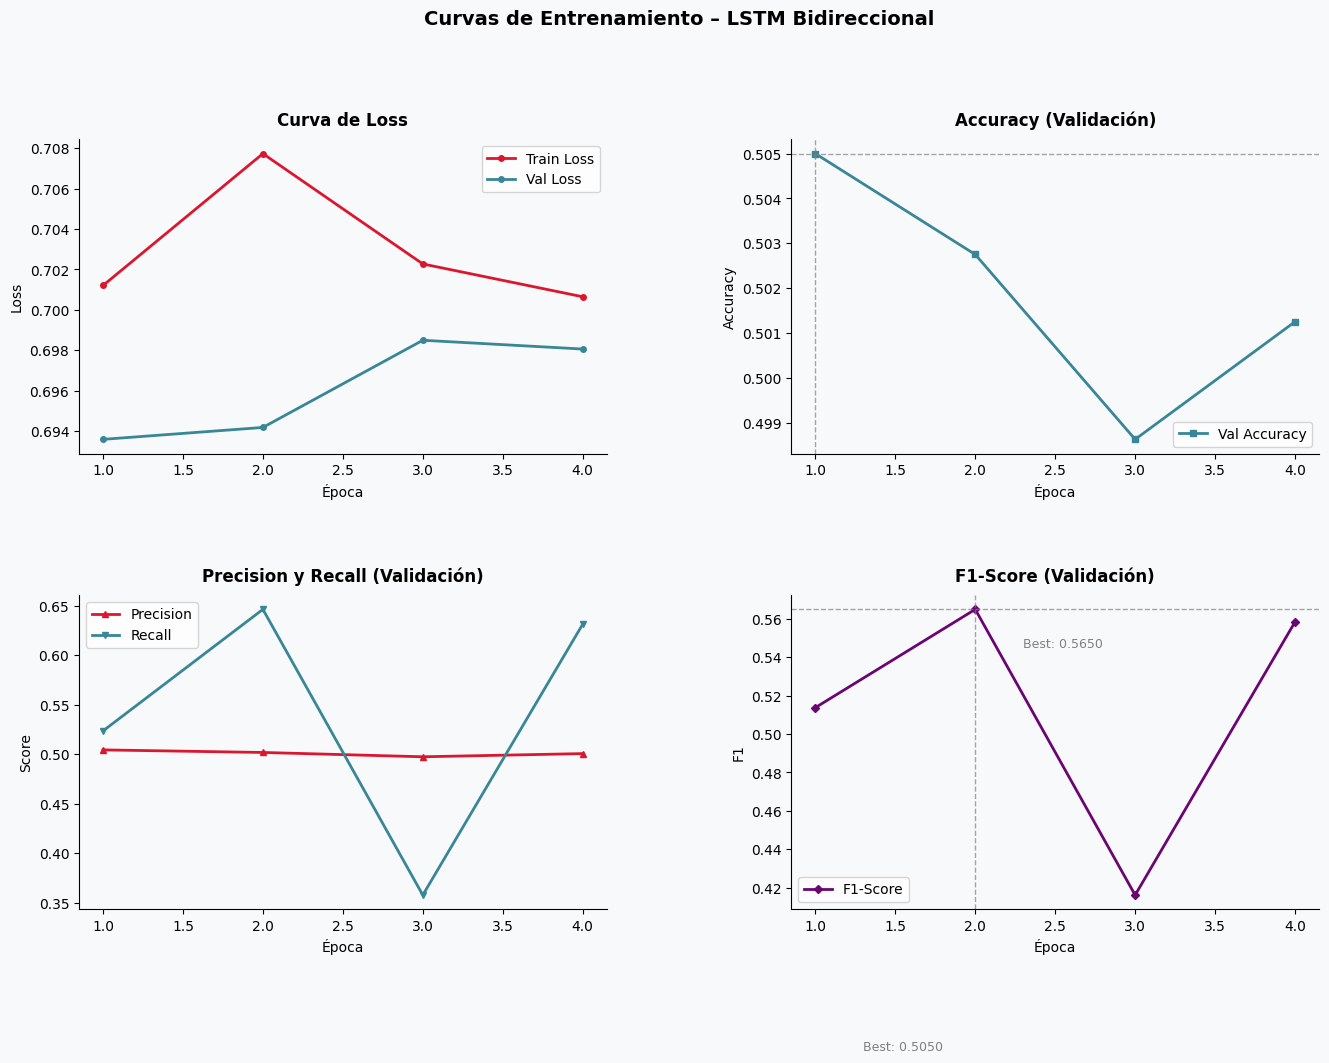

Figura guardada como training_curves.png


In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ── Funciones de entrenamiento y evaluación ──────────────────────────────────

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate_full(model, loader, criterion, device):
    """Retorna loss + las 4 métricas de clasificación."""
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            total_loss += criterion(outputs, y_batch).item()
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec  = recall_score(all_labels, all_preds, zero_division=0)
    f1   = f1_score(all_labels, all_preds, zero_division=0)
    return avg_loss, acc, prec, rec, f1

# ── Configuración del entrenamiento ─────────────────────────────────────────

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_rnn.to(DEVICE)

optimizer = torch.optim.Adam(model_rnn.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

# Reduce el lr a la mitad si val_loss no mejora en 2 épocas consecutivas
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5
)

# ── Inicializar history ──────────────────────────────────────────────────────

history = {
    "train_loss"   : [],
    "val_loss"     : [],
    "val_acc"      : [],
    "val_precision": [],
    "val_recall"   : [],
    "val_f1"       : []
}

# ── Early stopping ───────────────────────────────────────────────────────────

epochs            = 20
patience          = 3
best_val_loss     = float('inf')
epochs_no_improve = 0
best_model_state  = None

# ── Loop de entrenamiento ────────────────────────────────────────────────────

for epoch in range(1, epochs + 1):
    train_loss = train_epoch(model_rnn, train_loader, optimizer, criterion, DEVICE)
    val_loss, acc, prec, rec, f1 = evaluate_full(model_rnn, test_loader, criterion, DEVICE)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(acc)
    history["val_precision"].append(prec)
    history["val_recall"].append(rec)
    history["val_f1"].append(f1)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}"
    )

    # Guarda el mejor modelo y verifica criterio de parada
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model_rnn.state_dict().copy()
        epochs_no_improve = 0
        print(f"           ✓ Mejor modelo guardado (val_loss={best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        print(f"           Sin mejora {epochs_no_improve}/{patience}")
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping activado en época {epoch}.")
            break

# Restaurar pesos del mejor modelo antes de graficar
model_rnn.load_state_dict(best_model_state)
print("\nMejor modelo restaurado ✓")

# ── Curvas de entrenamiento ──────────────────────────────────────────────────

plot_training_curves(history, PAL, BG)

In [35]:
# ── Guardar el modelo RNN ────────────────────────────────────────────────────

# Guarda solo los pesos (recomendado por PyTorch)
torch.save(model_rnn.state_dict(), "model_rnn.pth")
print("Modelo RNN guardado como model_rnn.pth ✓")

# Guarda también el vocabulario por si necesitas encodear nuevos textos
import json
with open("vocab_rnn.json", "w") as f:
    json.dump(vocab, f)
print("Vocabulario guardado como vocab_rnn.json ✓")

Modelo RNN guardado como model_rnn.pth ✓
Vocabulario guardado como vocab_rnn.json ✓


## Modelo NUEVO MEJORADO

In [36]:
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=200,
        hidden_dim=256,
        output_dim=2,
        n_layers=2,
        dropout=0.3,
        bidirectional=True
    ):
        super().__init__()
        self.embedding   = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=0)
        self.emb_dropout = nn.Dropout(dropout)
        self.lstm        = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
            bidirectional=bidirectional
        )
        self.dropout  = nn.Dropout(dropout)
        fc_input_dim  = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc       = nn.Linear(fc_input_dim, output_dim)

    def forward(self, x):
        embedded            = self.emb_dropout(self.embedding(x))
        output, (hidden, _) = self.lstm(embedded)
        hidden_fwd          = hidden[-2, :, :]          # última capa, forward
        hidden_bwd          = hidden[-1, :, :]          # última capa, backward
        hidden_cat          = torch.cat([hidden_fwd, hidden_bwd], dim=1)
        return self.fc(self.dropout(hidden_cat))

model_lstm = LSTMClassifier(vocab_size=len(vocab)).to(DEVICE)
print(model_lstm)

LSTMClassifier(
  (embedding): Embedding(20001, 200, padding_idx=0)
  (emb_dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(200, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=2, bias=True)
)


In [38]:
def run_experiment(model, model_name, train_loader, test_loader,
                   epochs=20, patience=3, lr=3e-4):

    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=2, factor=0.5
    )

    history = {
        "train_loss": [], "val_loss"     : [],
        "val_acc"   : [], "val_precision": [],
        "val_recall": [], "val_f1"       : []
    }

    best_val_loss     = float('inf')
    best_model_state  = None
    epochs_no_improve = 0

    print(f"\n{'═'*60}")
    print(f"  Entrenando: {model_name}")
    print(f"{'═'*60}")

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss, acc, prec, rec, f1 = evaluate_full(
            model, test_loader, criterion, DEVICE
        )
        lr_antes = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        lr_despues = optimizer.param_groups[0]['lr']

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(acc)
        history["val_precision"].append(prec)
        history["val_recall"].append(rec)
        history["val_f1"].append(f1)

        lr_tag = f" ↓lr→{lr_despues:.2e}" if lr_despues < lr_antes else ""
        print(
            f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | Acc: {acc:.4f} | "
            f"Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}{lr_tag}"
        )

        if val_loss < best_val_loss:
            best_val_loss     = val_loss
            best_model_state  = model.state_dict().copy()
            epochs_no_improve = 0
            print(f"           ✓ Mejor modelo guardado (val_loss={best_val_loss:.4f})")
        else:
            epochs_no_improve += 1
            print(f"           Sin mejora {epochs_no_improve}/{patience}")
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping activado en época {epoch}.")
                break

    model.load_state_dict(best_model_state)
    print(f"\nMejor modelo restaurado ✓")
    return history

In [39]:
history_rnn  = run_experiment(
    model_rnn,  "RNN Vanilla",
    train_loader, test_loader, lr=1e-3
)

history_lstm = run_experiment(
    model_lstm, "LSTM Bidireccional",
    train_loader, test_loader, lr=3e-4
)


════════════════════════════════════════════════════════════
  Entrenando: RNN Vanilla
════════════════════════════════════════════════════════════
Epoch 01 | Train Loss: 0.7017 | Val Loss: 0.7036 | Acc: 0.5129 | Prec: 0.5184 | Rec: 0.3483 | F1: 0.4167
           ✓ Mejor modelo guardado (val_loss=0.7036)
Epoch 02 | Train Loss: 0.7009 | Val Loss: 0.6962 | Acc: 0.5005 | Prec: 0.5000 | Rec: 0.5993 | F1: 0.5452
           ✓ Mejor modelo guardado (val_loss=0.6962)
Epoch 03 | Train Loss: 0.7010 | Val Loss: 0.6935 | Acc: 0.5058 | Prec: 0.5037 | Rec: 0.7247 | F1: 0.5943
           ✓ Mejor modelo guardado (val_loss=0.6935)
Epoch 04 | Train Loss: 0.7013 | Val Loss: 0.7006 | Acc: 0.4956 | Prec: 0.4953 | Rec: 0.5100 | F1: 0.5025
           Sin mejora 1/3
Epoch 05 | Train Loss: 0.7005 | Val Loss: 0.6943 | Acc: 0.5108 | Prec: 0.5069 | Rec: 0.7528 | F1: 0.6058
           Sin mejora 2/3
Epoch 06 | Train Loss: 0.7019 | Val Loss: 0.7010 | Acc: 0.4981 | Prec: 0.4985 | Rec: 0.8076 | F1: 0.6165 ↓lr→5.00e-

In [40]:
torch.save(model_rnn.state_dict(),  "model_rnn.pth")
torch.save(model_lstm.state_dict(), "model_lstm.pth")
print("Modelos guardados ✓")

Modelos guardados ✓


In [41]:

def best_metrics(history, model_name):
    best_ep = history["val_f1"].index(max(history["val_f1"]))
    return {
        "Modelo"   : model_name,
        "Accuracy" : round(history["val_acc"][best_ep], 4),
        "Precision": round(history["val_precision"][best_ep], 4),
        "Recall"   : round(history["val_recall"][best_ep], 4),
        "F1-Score" : round(history["val_f1"][best_ep], 4),
        "Val Loss" : round(history["val_loss"][best_ep], 4),
    }

tabla = pd.DataFrame([
    best_metrics(history_rnn,  "RNN Vanilla"),
    best_metrics(history_lstm, "LSTM Bidireccional"),
])
print("\n── Comparación de Modelos ──────────────────────────")
print(tabla.to_string(index=False))




── Comparación de Modelos ──────────────────────────
            Modelo  Accuracy  Precision  Recall  F1-Score  Val Loss
       RNN Vanilla    0.4981     0.4985  0.8076    0.6165    0.7010
LSTM Bidireccional    0.8892     0.8709  0.9137    0.8918    0.3213


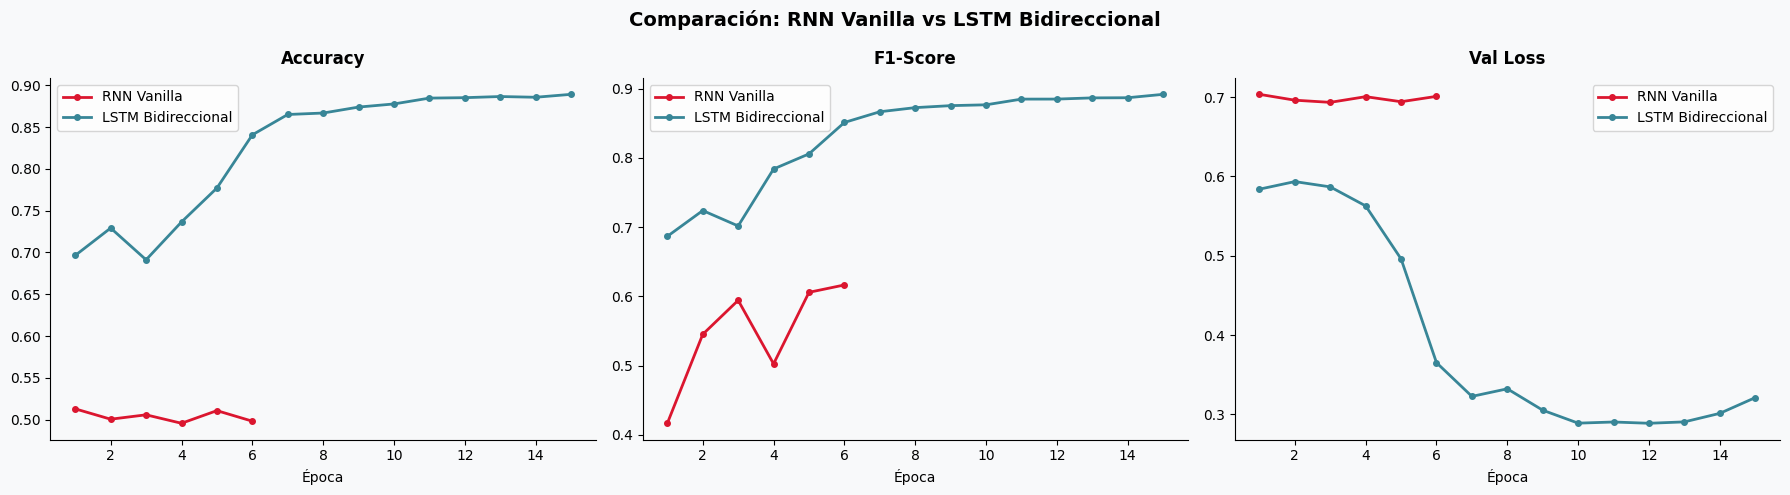

In [42]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG)

metricas = ["val_acc", "val_f1",    "val_loss"]
titulos  = ["Accuracy", "F1-Score", "Val Loss"]
colores  = {
    "RNN Vanilla"        : PAL["Negativa"],
    "LSTM Bidireccional" : PAL["Positiva"]
}

for ax, metrica, titulo in zip(axes, metricas, titulos):
    for hist, nombre in [(history_rnn,  "RNN Vanilla"),
                         (history_lstm, "LSTM Bidireccional")]:
        ax.plot(
            range(1, len(hist[metrica]) + 1), hist[metrica],
            label=nombre, color=colores[nombre],
            linewidth=2, marker="o", markersize=4
        )
    ax.set_title(titulo, fontweight="bold", pad=10)
    ax.set_xlabel("Época")
    ax.legend()
    ax.set_facecolor(BG)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Comparación: RNN Vanilla vs LSTM Bidireccional",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("comparacion_modelos.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


═══════════════════════════════════════════════════════
  Classification Report — RNN Vanilla
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

    Negativa       0.50      0.19      0.27      4004
    Positiva       0.50      0.81      0.62      3996

    accuracy                           0.50      8000
   macro avg       0.50      0.50      0.45      8000
weighted avg       0.50      0.50      0.45      8000



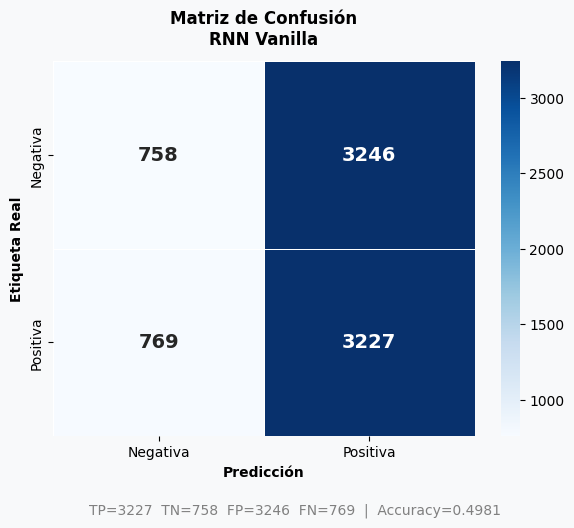

Figura guardada como confusion_matrix_rnn_vanilla.png ✓

═══════════════════════════════════════════════════════
  Classification Report — LSTM Bidireccional
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

    Negativa       0.91      0.86      0.89      4004
    Positiva       0.87      0.91      0.89      3996

    accuracy                           0.89      8000
   macro avg       0.89      0.89      0.89      8000
weighted avg       0.89      0.89      0.89      8000



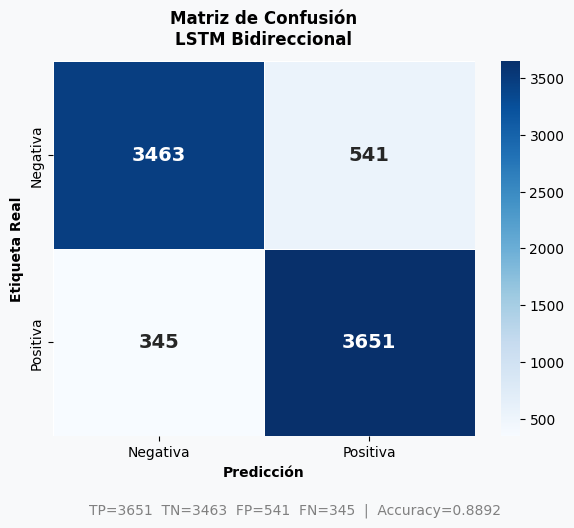

Figura guardada como confusion_matrix_lstm_bidireccional.png ✓

═══════════════════════════════════════════════════════
  Inferencia — RNN Vanilla
═══════════════════════════════════════════════════════
  Texto      : This movie was absolutely fantastic, the acting was outstanding!...
  Sentimiento: Positiva ✓
  Confianza  : Positiva=0.5539 | Negativa=0.4461

  Texto      : Terrible film, complete waste of time. The plot made no sense at all....
  Sentimiento: Positiva ✓
  Confianza  : Positiva=0.5539 | Negativa=0.4461

  Texto      : It was okay, nothing special but not bad either....
  Sentimiento: Positiva ✓
  Confianza  : Positiva=0.5539 | Negativa=0.4461

  Texto      : One of the best movies I have ever seen in my entire life!...
  Sentimiento: Negativa ✗
  Confianza  : Positiva=0.4236 | Negativa=0.5764

  Texto      : I fell asleep halfway through, incredibly boring and predictable....
  Sentimiento: Positiva ✓
  Confianza  : Positiva=0.5539 | Negativa=0.4461


═════════════════

In [44]:

def evaluar_modelo(model, loader, model_name, device, PAL, BG):
    """
    Corre el modelo sobre el loader, imprime el classification report
    y grafica la matriz de confusión.
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            outputs = model(x_batch)
            preds   = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    # ── Classification Report ────────────────────────────────────────────────
    print(f"\n{'═'*55}")
    print(f"  Classification Report — {model_name}")
    print(f"{'═'*55}")
    print(classification_report(
        all_labels, all_preds,
        target_names=["Negativa", "Positiva"]
    ))

    # ── Matriz de Confusión ──────────────────────────────────────────────────
    cm = confusion_matrix(all_labels, all_preds)

    fig, ax = plt.subplots(figsize=(6, 5), facecolor=BG)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Negativa", "Positiva"],
        yticklabels=["Negativa", "Positiva"],
        linewidths=0.5, linecolor="white",
        annot_kws={"size": 14, "weight": "bold"},
        ax=ax
    )
    ax.set_title(f"Matriz de Confusión\n{model_name}",
                 fontweight="bold", pad=12)
    ax.set_xlabel("Predicción", fontweight="bold")
    ax.set_ylabel("Etiqueta Real", fontweight="bold")
    ax.set_facecolor(BG)

    # Añadir métricas resumen debajo del gráfico
    tn, fp, fn, tp = cm.ravel()
    acc  = (tp + tn) / cm.sum()
    fig.text(
        0.5, -0.04,
        f"TP={tp}  TN={tn}  FP={fp}  FN={fn}  |  Accuracy={acc:.4f}",
        ha="center", fontsize=10, color="gray"
    )

    plt.tight_layout()
    fname = f"confusion_matrix_{model_name.lower().replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show()
    print(f"Figura guardada como {fname} ✓")

    return all_preds, all_labels


# ── Evaluación de ambos modelos ──────────────────────────────────────────────

preds_rnn,  labels_rnn  = evaluar_modelo(model_rnn,  test_loader, "RNN Vanilla",        DEVICE, PAL, BG)
preds_lstm, labels_lstm = evaluar_modelo(model_lstm, test_loader, "LSTM Bidireccional",  DEVICE, PAL, BG)


# ════════════════════════════════════════════════════════════════════════════
# INFERENCIA — Probar con reseñas propias
# ════════════════════════════════════════════════════════════════════════════

def predecir(texto, model, vocab, device, max_len=256):
    """Predice el sentimiento de un texto nuevo."""
    model.eval()
    tokens = encode(texto, vocab, max_len=max_len)
    x      = torch.tensor([tokens], dtype=torch.long).to(device)
    with torch.no_grad():
        output = model(x)
        prob   = torch.softmax(output, dim=1)[0]
        pred   = output.argmax(dim=1).item()
    etiqueta = "Positiva ✓" if pred == 1 else "Negativa ✗"
    print(f"  Texto      : {texto[:80]}...")
    print(f"  Sentimiento: {etiqueta}")
    print(f"  Confianza  : Positiva={prob[1]:.4f} | Negativa={prob[0]:.4f}")
    print()
    return pred


# ── Ejemplos de prueba ───────────────────────────────────────────────────────

resenas = [
    "This movie was absolutely fantastic, the acting was outstanding!",
    "Terrible film, complete waste of time. The plot made no sense at all.",
    "It was okay, nothing special but not bad either.",
    "One of the best movies I have ever seen in my entire life!",
    "I fell asleep halfway through, incredibly boring and predictable.",
]

print(f"\n{'═'*55}")
print(f"  Inferencia — RNN Vanilla")
print(f"{'═'*55}")
for r in resenas:
    predecir(r, model_rnn, vocab, DEVICE)

print(f"\n{'═'*55}")
print(f"  Inferencia — LSTM Bidireccional")
print(f"{'═'*55}")
for r in resenas:
    predecir(r, model_lstm, vocab, DEVICE)

In [45]:
print(f"\n{'═'*55}")
print(f"  Inferencia — LSTM Bidireccional")
print(f"{'═'*55}")
for r in resenas:
    predecir(r, model_lstm, vocab, DEVICE)


═══════════════════════════════════════════════════════
  Inferencia — LSTM Bidireccional
═══════════════════════════════════════════════════════
  Texto      : This movie was absolutely fantastic, the acting was outstanding!...
  Sentimiento: Positiva ✓
  Confianza  : Positiva=0.9970 | Negativa=0.0030

  Texto      : Terrible film, complete waste of time. The plot made no sense at all....
  Sentimiento: Negativa ✗
  Confianza  : Positiva=0.0007 | Negativa=0.9993

  Texto      : It was okay, nothing special but not bad either....
  Sentimiento: Negativa ✗
  Confianza  : Positiva=0.4344 | Negativa=0.5656

  Texto      : One of the best movies I have ever seen in my entire life!...
  Sentimiento: Positiva ✓
  Confianza  : Positiva=0.9940 | Negativa=0.0060

  Texto      : I fell asleep halfway through, incredibly boring and predictable....
  Sentimiento: Negativa ✗
  Confianza  : Positiva=0.0006 | Negativa=0.9994



## GloVe

In [46]:

import urllib.request
import zipfile
import os

glove_zip  = "glove.6B.zip"
glove_file = "glove.6B.200d.txt"

if not os.path.exists(glove_file):
    print("Descargando GloVe... (puede tardar unos minutos)")
    urllib.request.urlretrieve(
        "https://nlp.stanford.edu/data/glove.6B.zip",
        glove_zip
    )
    print("Descomprimiendo...")
    with zipfile.ZipFile(glove_zip, "r") as z:
        z.extract(glove_file)
    print("GloVe listo ✓")
else:
    print("GloVe ya existe, se omite la descarga ✓")


Descargando GloVe... (puede tardar unos minutos)
Descomprimiendo...
GloVe listo ✓


In [47]:
def load_glove(glove_path, vocab, embed_dim=200):
    """
    Carga los vectores GloVe para las palabras que están en el vocabulario.
    Las palabras no encontradas en GloVe quedan como vector de ceros
    y el modelo las aprenderá desde cero durante el entrenamiento.
    """
    # vocab_size + 1 por el token de padding (índice 0)
    embedding_matrix = np.zeros((len(vocab) + 1, embed_dim))
    encontradas = 0

    with open(glove_path, encoding="utf-8") as f:
        for line in f:
            values = line.split()
            word   = values[0]
            vector = np.asarray(values[1:], dtype="float32")
            if word in vocab:
                idx = vocab[word]
                embedding_matrix[idx] = vector
                encontradas += 1

    cobertura = encontradas / len(vocab) * 100
    print(f"Palabras del vocabulario cubiertas por GloVe: "
          f"{encontradas}/{len(vocab)} ({cobertura:.1f}%)")
    return torch.tensor(embedding_matrix, dtype=torch.float)


glove_matrix = load_glove(glove_file, vocab, embed_dim=200)

Palabras del vocabulario cubiertas por GloVe: 19895/20000 (99.5%)


In [48]:
class LSTMGloVe(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_matrix,   # recibe la matriz preentrenada
        embed_dim=200,
        hidden_dim=256,
        output_dim=2,
        n_layers=2,
        dropout=0.3,
        bidirectional=True,
        freeze_embeddings=False  # True = embeddings fijos, False = fine-tuning
    ):
        super().__init__()

        # Inicializar con pesos GloVe en lugar de pesos aleatorios
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(embedding_matrix)
        self.embedding.weight.requires_grad = not freeze_embeddings

        self.emb_dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
            bidirectional=bidirectional
        )
        self.dropout     = nn.Dropout(dropout)
        fc_input_dim     = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc          = nn.Linear(fc_input_dim, output_dim)

    def forward(self, x):
        embedded            = self.emb_dropout(self.embedding(x))
        output, (hidden, _) = self.lstm(embedded)
        hidden_fwd          = hidden[-2, :, :]
        hidden_bwd          = hidden[-1, :, :]
        hidden_cat          = torch.cat([hidden_fwd, hidden_bwd], dim=1)
        return self.fc(self.dropout(hidden_cat))


model_glove = LSTMGloVe(
    vocab_size        = len(vocab),
    embedding_matrix  = glove_matrix,
    freeze_embeddings = False   # fine-tuning: los embeddings se ajustan durante el entrenamiento
).to(DEVICE)

print(model_glove)

LSTMGloVe(
  (embedding): Embedding(20001, 200, padding_idx=0)
  (emb_dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(200, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=2, bias=True)
)


In [49]:
history_glove = run_experiment(
    model_glove, "LSTM + GloVe",
    train_loader, test_loader,
    epochs=20, patience=3, lr=3e-4
)

# Guardar el modelo
torch.save(model_glove.state_dict(), "model_lstm_glove.pth")
print("Modelo LSTM+GloVe guardado ✓")


════════════════════════════════════════════════════════════
  Entrenando: LSTM + GloVe
════════════════════════════════════════════════════════════
Epoch 01 | Train Loss: 0.6234 | Val Loss: 0.5827 | Acc: 0.7261 | Prec: 0.8117 | Rec: 0.5881 | F1: 0.6820
           ✓ Mejor modelo guardado (val_loss=0.5827)
Epoch 02 | Train Loss: 0.5394 | Val Loss: 0.6767 | Acc: 0.6321 | Prec: 0.9551 | Rec: 0.2765 | F1: 0.4289
           Sin mejora 1/3
Epoch 03 | Train Loss: 0.5918 | Val Loss: 0.7156 | Acc: 0.5072 | Prec: 0.8000 | Rec: 0.0180 | F1: 0.0352
           Sin mejora 2/3
Epoch 04 | Train Loss: 0.6249 | Val Loss: 0.4717 | Acc: 0.7959 | Prec: 0.7541 | Rec: 0.8774 | F1: 0.8111
           ✓ Mejor modelo guardado (val_loss=0.4717)
Epoch 05 | Train Loss: 0.3728 | Val Loss: 0.3209 | Acc: 0.8718 | Prec: 0.8859 | Rec: 0.8531 | F1: 0.8692
           ✓ Mejor modelo guardado (val_loss=0.3209)
Epoch 06 | Train Loss: 0.2891 | Val Loss: 0.2877 | Acc: 0.8810 | Prec: 0.8869 | Rec: 0.8731 | F1: 0.8799
         

In [50]:
tabla = pd.DataFrame([
    best_metrics(history_rnn,   "RNN Vanilla"),
    best_metrics(history_lstm,  "LSTM Bidireccional"),
    best_metrics(history_glove, "LSTM + GloVe"),
])
print("\n── Comparación Final de Modelos ────────────────────────")
print(tabla.to_string(index=False))


── Comparación Final de Modelos ────────────────────────
            Modelo  Accuracy  Precision  Recall  F1-Score  Val Loss
       RNN Vanilla    0.4981     0.4985  0.8076    0.6165    0.7010
LSTM Bidireccional    0.8892     0.8709  0.9137    0.8918    0.3213
      LSTM + GloVe    0.8919     0.8676  0.9247    0.8952    0.2853


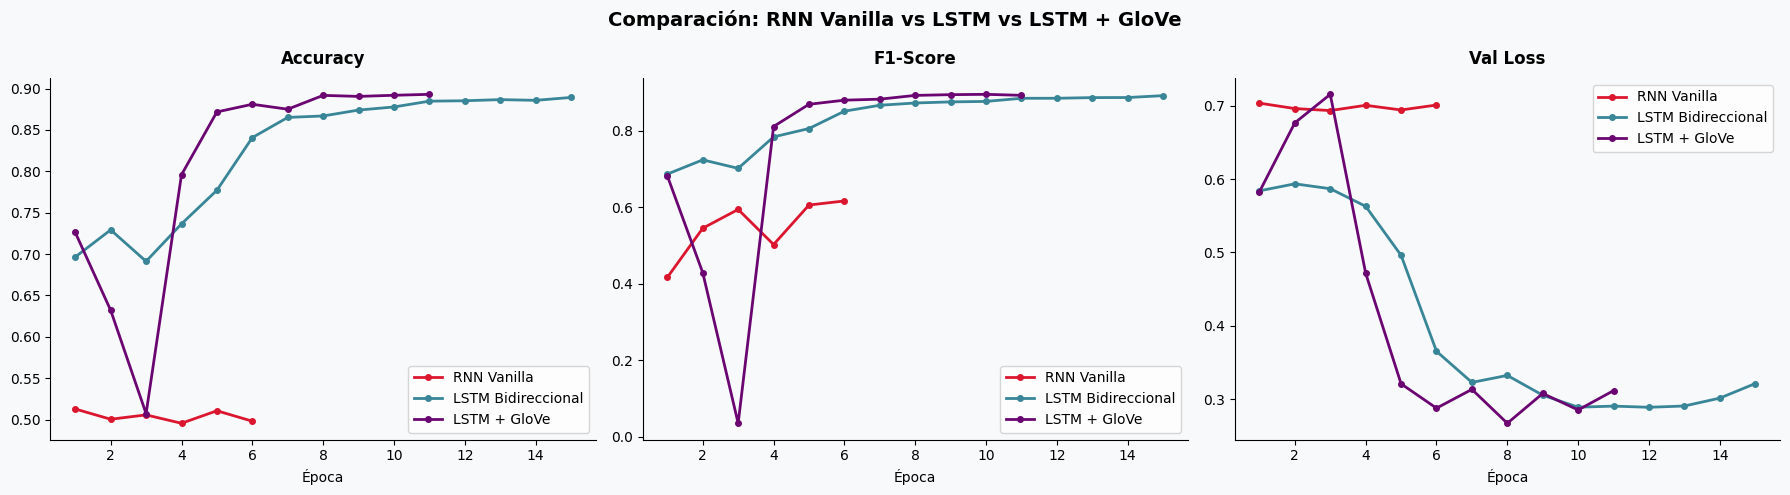

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG)

metricas = ["val_acc",    "val_f1",    "val_loss"]
titulos  = ["Accuracy",   "F1-Score",  "Val Loss"]
colores  = {
    "RNN Vanilla"        : PAL["Negativa"],
    "LSTM Bidireccional" : PAL["Positiva"],
    "LSTM + GloVe"       : "#6A0572",
}

for ax, metrica, titulo in zip(axes, metricas, titulos):
    for hist, nombre in [
        (history_rnn,   "RNN Vanilla"),
        (history_lstm,  "LSTM Bidireccional"),
        (history_glove, "LSTM + GloVe"),
    ]:
        ax.plot(
            range(1, len(hist[metrica]) + 1), hist[metrica],
            label=nombre, color=colores[nombre],
            linewidth=2, marker="o", markersize=4
        )
    ax.set_title(titulo, fontweight="bold", pad=10)
    ax.set_xlabel("Época")
    ax.legend()
    ax.set_facecolor(BG)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Comparación: RNN Vanilla vs LSTM vs LSTM + GloVe",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("comparacion_tres_modelos.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()